# Распознавание рукописных цифр нейронной сетью с плотными слоями

Практическое занятие №3

Здесь создается и обучается нейронная сеть для распознавания цифр, изображенных на картинках. То есть на вход нейросети будет приходить картинка с числом, а на выходе вы получите само число.

In [53]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

Для начала добавьте в проект все необходимые модули:
* `mnist` – для загрузки набора данных, который вы используете при обучении нейронной сети;
* `sequential` – базовый модуль для создания нейронной сети;
* `Dense` – линейный (полносвязный) слой. Из таких слоев будет создана ваша нейросеть;
* `Adam` – оптимизатор, который вы используете для обучения;
* `utils` – модуль, который содержит некоторые полезные инструменты;
* `image` и `Image` – инструменты для работы с картинками;
* `pylab` и `plt` – с помощью этих модулей вы нарисуете графики.

In [54]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


**Создаем последовательную модель**

Вначале создается объект нейронной сети с помощью класса Sequential:

    model = Sequential()

Сейчас это пустая нейронная сеть, не содержащая в себе никаких слоев и нейронов. В нее нужно добавить несколько слоев нейронов, идущих друг за другом, последовательно:

    model.add(Dense(800, activation="relu"))
    
В данном случае 800 – это количество нейронов в слое, а 'relu' – функция активации, которая будет применяться к данным после выхода из данного слоя.

In [63]:
model = Sequential()
# Входной полносвязный слой, 800 нейронов, 784 входа в каждый нейрон
model.add(Dense(800, input_dim=784, activation="relu"))
# Выходной полносвязный слой, 10 нейронов (по количеству рукописных цифр)
model.add(Dense(10, activation="softmax"))

###Компилируем сеть

In [64]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,010 (2.43 MB)

 Trainable params: 636,010 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

None


Метод `summary` выводит на экран структуру вашей нейронной сети: то как она выглядит изнутри:

###Обучаем нейронную сеть

Одной строчкой кода запускается обучение нейронной сети и есть возможность наблюдать за процессом.

Для этого вызовите метод `fit` и передайте ему данные для обучения `(x_train, y_train)`:
    model.fit(x_train, y_train, batch_size=200, epochs=2, verbose=1)

`batch_size` – параметр, который указывает нейросети на то, сколько картинок она будет обрабатывать за один раз.

`epochs` – это количество циклов обучения, то есть сколько раз нейронная сеть просмотрит все ваши данные и обучится на них.

In [65]:
#fit - функция обучения нейронной сети
#x_train, y_train - обучающая выборка, входные и выходные данные
#batch_size - размер батча, количество примеров, которое обрабатывает нейронка перед одним изменением весов
#epochs - количество эпох, когда нейронка обучается на всех примерах выборки
#verbose - 0 - не визуализировать ход обучения, 1 - визуализировать
model.fit(x_train, y_train, batch_size=200, epochs=2,  verbose=1)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9233 - loss: 0.2731
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9680 - loss: 0.1116


Представлен процесс обучения нейронной сети. После каждого цикла обучения вы можете видеть среднее значение ошибки. Обратите внимание, что практически каждую эпоху значение метрики точности (accuracy) увеличивается. Это означает, что ваша нейронная сеть с каждым разом делает все более точные предсказания!

###Запускаем распознавание

In [66]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 97.17%


Чтобы сеть выдала ответ, нужно вызвать метод predict и передать в него данные для распознавания:

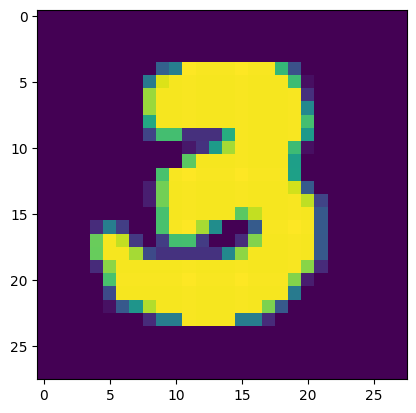

3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
[[3.1627178e-07 1.5194102e-09 4.4505960e-05 9.9801588e-01 1.7873368e-10
  1.1698694e-04 2.8045907e-10 1.7271468e-10 1.8222965e-03 5.4323301e-09]]


In [67]:
n=200
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test_org[n,:,:]
X = X.reshape(1, 784)
X = X.astype('float32')
X = X / 255
prediction = model.predict(X)
print(prediction)

Эти числа представляют собой вероятности принадлежности к конкретному классу. Самое первое число в этой последовательности говорит о том, какова вероятность, что на картинке изображена цифра 0. Второе число говорит то же самое про цифру 1. То есть индекс самой большой вероятности в этом списке чисел и будет ответом вашей нейронной сети:

In [68]:
prediction_N = np.argmax(prediction)
print(prediction_N)
print(np.sum(prediction))

3
1.0


**Сохраняем обученную нейронную сеть в файл mnist_dense.h5**

In [69]:
model.save("mnist_dense.h5")

Сохраняем файлы на локальный компьютер

In [70]:
from google.colab import files
files.download("mnist_dense.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
#Если хотите использовать обученную нейронную сеть на своем компьютере:
from tensorflow import keras
import h5py
model = keras.models.load_model('mnist_dense.h5')

Сохранение сети через json

In [72]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего
# использования Генерируем описание модели
# в формате json
model_json = model.to_json()
json_file = open("mnist_model.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [73]:
#from keras.utils import np_utils
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


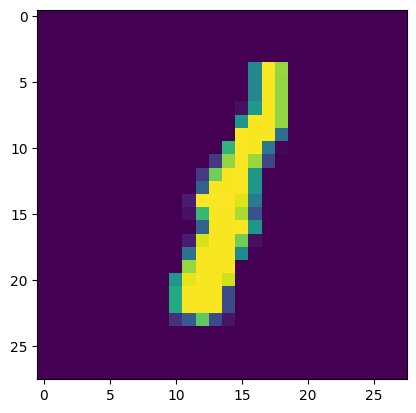

1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
[[1.94175414e-06 9.97204483e-01 4.73112246e-04 3.89946450e-04
  3.22328793e-04 9.12974065e-05 1.00697696e-04 6.53833908e-04
  7.44096062e-04 1.84798828e-05]]


In [74]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test_org[n,:,:]
X = X.reshape(1, 784)
X = X.astype('float32')
X = X / 255
prediction = loaded_model.predict(X)
print(prediction)

In [75]:
prediction = np.argmax(prediction)
print(prediction)

1


# Распознавание рукописных цифр сверточной нейронной сетью

In [76]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

In [77]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

In [78]:
print(x_train_org.shape)
print(y_train_org.shape)
print(x_test_org.shape)
print(y_test_org.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [79]:
x_train = x_train_org.astype('float32')
x_train = x_train / 255

x_test = x_test_org.astype('float32')
x_test = x_test / 255

In [80]:
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

In [81]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [82]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

In [83]:
model = Sequential()
#model.add(BatchNormalization(input_shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=(4, 4), padding='same', input_shape=(28, 28, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(4, 4), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [84]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,746 (1.65 MB)

 Trainable params: 432,554 (1.65 MB)

 Non-trainable params: 192 (768.00 B)

None


In [85]:
model.fit(x_train, y_train, batch_size=200, epochs=7,  verbose=1)

Epoch 1/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9127 - loss: 0.2805
Epoch 2/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9785 - loss: 0.0716
Epoch 3/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9833 - loss: 0.0538
Epoch 4/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9866 - loss: 0.0440
Epoch 5/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9888 - loss: 0.0380
Epoch 6/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9895 - loss: 0.0341
Epoch 7/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9901 - loss: 0.0320


In [86]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 99.32%


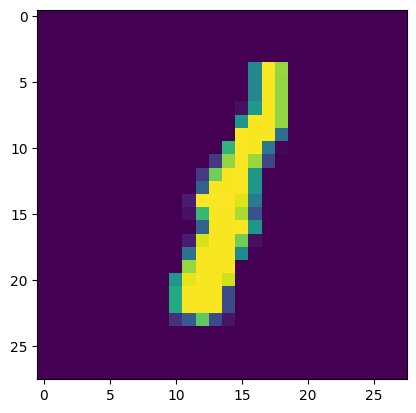

1
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
[[6.2582409e-08 9.9999881e-01 4.7011701e-09 5.2810729e-09 3.9831974e-07
  7.3480912e-08 1.7925994e-07 8.3223334e-08 2.7693903e-07 4.9997070e-08]]


In [87]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = model.predict(X)
print(prediction)

In [88]:
prediction = np.argmax(prediction)
print(prediction)

1


In [89]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model_CNN.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model_CNN.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [90]:
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model_CNN.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model_CNN.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


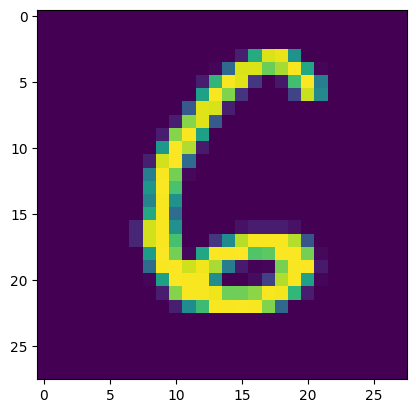

6
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
[[5.6993819e-08 3.6386349e-11 1.0922840e-09 7.5031292e-10 6.4503274e-09
  2.7175106e-06 9.9999392e-01 1.7538971e-14 3.2797382e-06 3.8764791e-10]]


In [91]:
n=98
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = loaded_model.predict(X)
print(prediction)

In [92]:
prediction = np.argmax(prediction)
print(prediction)

6


# Тестирование собственного изображения

(28, 28, 3)


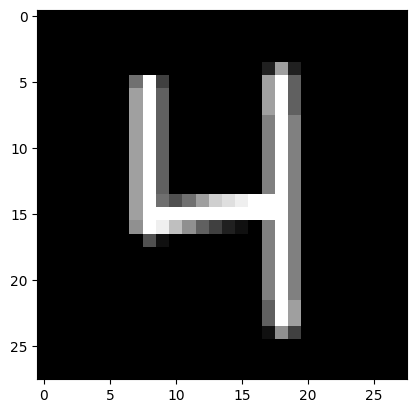

(28, 28)


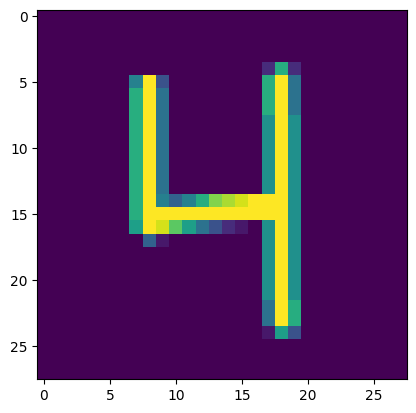

In [105]:
import cv2

#Загружаем изображение
image = cv2.imread('/content/gdrive/MyDrive/black_four.png')
print(image.shape)
plt.imshow(image)
plt.show()
#Загружаем изображение в оттенках серого
image = cv2.imread('/content/gdrive/MyDrive/black_four.png', cv2.IMREAD_GRAYSCALE)
print(image.shape)
#Отображение файла встроенными средствами OpenCV.
plt.imshow(image)
plt.show()

In [106]:
dim=(28,28)
resized = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)
print(resized.shape)

(28, 28)


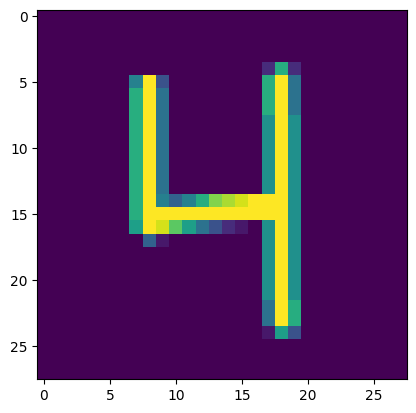

In [107]:
plt.imshow(resized.reshape(28,28))

In [108]:
resized  = resized.astype('float32')
resized = resized / 255

In [109]:
resized = np.expand_dims(resized, axis=0)
resized = np.expand_dims(resized, axis=3)
print(resized.shape)

(1, 28, 28, 1)


In [110]:
prediction = loaded_model.predict(resized)
print(prediction)
prediction = np.argmax(prediction)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[4.8931734e-15 1.1013743e-09 1.4630507e-11 4.3458099e-14 1.0000000e+00
  1.8407617e-12 2.2039747e-11 8.2935228e-11 9.5494420e-12 8.3915328e-09]]
4
